#### Name: Jon Stowers

# PHYS 230 Lab Assignment 9

### Monday, February 23, 2026: Chapter 5.5-5.9
- Evaluating integrals in python 
    - Gaussian Quadrature 
    - Infinite integrals
    - Multiple integrals

***Don't forget to include comments in your code and a final markdown explanation at the end of each problem.***

In [7]:
# put all import statements here
import numpy as np
import matplotlib.pyplot as plt
from gaussxw import gaussxw


## Gaussian Quadrature 1 (22 pts)

Consider the integral from last lab $$\int_{1.1}^{10.1} \frac{\sin{x}}{\ln{x}} \,dx $$ a) Re-evaulate the integral using Gaussian quadrature with 𝑁=10 points 

b) Repeat the evaluation with 2𝑁 points and evaluate the error.  

c) Compare these results with your results for both the trapezoidal and Simpson’s rules


In [2]:
# part a

def f(x):
    return np.sin(x)/np.log(x)



a = 1.1
b = 10.1
N = 10

x,w = gaussxw(N,a,b)



I = 0.0
for k in range(N):
    I += w[k]*f(x[k])
print('For N=10 points, the integral is',I)





For N=10 points, the integral is 2.7929415637242574


In [3]:
# part b

x2,w2 = gaussxw(2*N,a,b)

I2 = 0.0
for k in range(N*2):
    I2 += w2[k]*f(x2[k])
print('For 2N points, the integral is',I2)



For 2N points, the integral is 2.84805880772841


In [6]:
# part c

#Dr. DeGroot's code from Class Notebook 10 (Thanks!)
def trapezoidal_int(a,b,N,f): 
    # a = lower limit of integration 
    # b = upper limit of integration 
    # N = number of steps 
    # func = function that you are integrating, should be a user-defined function 
    
    # calculate h - width of each step
    h = (b-a)/N

    #integrate using extended trapezoidal rule
    s = 0.5*f(a)+0.5*f(b)
    for k in range(1,N):
        s += f(a+k*h)
    I = h*s

    # return value of the integral 
    return(I)

def simpsons_int(a,b,N,f): 
    # a = lower limit of integration 
    # b = upper limit of integration 
    # N = number of steps 
    # func = function that you are integrating, should be a user-defined function 
    
    # calculate h - width of each step
    h = (b-a)/N

    # evaluate using simpson's rule
    s = f(a) + f(b)
    for k in range(1,N):
        if k%2 == 1: # checking for odd
            s+= 4*f(a+k*h)
        else:
            s += 2*f(a+k*h)
    I = h/3*s

    # return value of the integral 
    return(I)



ITrapezoidal = trapezoidal_int(a,b,100,f)
ISimpsons = simpsons_int(a,b,100,f)

print('From the last lab, my integral using the trapezoidal rule for N = 100 points was',ITrapezoidal)
print('From the last lab, my integral using the Simpson\'s rule for N = 100 points was',ISimpsons)
print()
print('Compared to this lab\'s calculation using Gaussian Quadrature for 20 points is',I2)











From the last lab, my integral using the trapezoidal rule for N = 100 points was 2.9021883624907003
From the last lab, my integral using the Simpson's rule for N = 100 points was 2.856855482008929

Compared to this lab's calculation using Gaussian Quadrature for 20 points is 2.84805880772841


Comparing the values for the integral to the Gaussian Quadrature definition (which I'm assuming is perfect for comparison's sake), the accurace of G. Quadrature with only 10 points is comparable to the accuracy of trapezoidal with 100 results. This shows yet again that G. Quadrature can reach greater accuracy with a much smaller N than the other methods we've learned.

## Gaussian Quadrature 2 (22 pts)

One of the caveats of Gaussian Quadrature is that the function being integrated must be relatively smooth. With this in mind, let’s integrate the function $$ f(x) = e^{-x^2/2}$$ from 𝑥=0 to 𝑥=1.5 using 2 sample points. 


a) First, make a plot of $f(x)$ vs. $x$ for 50 points within the limits of integration. Is this function smooth? Do we expect the method of GQ to return an accurate result? 

b) Determine and print out the values of the sample points and weights for this problem. 
Evaluate the integral. 

c) Double the number of sample points and apply parts (b) and (c) until your error is less than our desired accuracy of $10^{−5}$


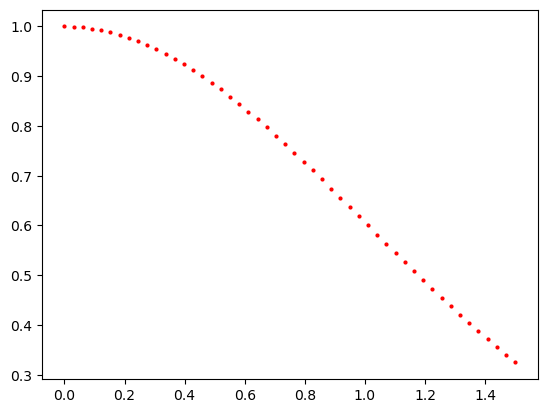

In [ ]:
#a)

def f(x):
    return np.exp(-0.5*x**2)

a = 0
b = 1.5
NumPoints = 50

xvals = np.linspace(a,b,NumPoints)
yvals = f(xvals)

plt.scatter(xvals,yvals,c='r',s=4)
plt.show()


This function does appear smooth, so Gaussian Quadrature should return an accurate answer!

In [22]:
#b)
N = 2 #starting number of points for GQ method so that later loop can evaluate the error


x,w = gaussxw(N,a,b)
print('The sample points are',x)
print('The weights are',w)


I = 0.0
for k in range(N):
    I += w[k]*f(x[k])

print('The value of the integral for N =',N,'is',I)



The sample points are [1.1830127 0.3169873]
The weights are [0.75 0.75]
The value of the integral for N = 2 is 1.0857790801898561


In [21]:
#c)

NewI = 0.0
NewN = N
error = NewI - I
while np.abs(error)>=1e-4:
    NewN *= 2 #doubles every time
    x,w = gaussxw(NewN,a,b)
    NewI = 0.0
    for k in range(NewN):
        NewI += w[k]*f(x[k])
    error = NewI - I

print('The new value of the integral is',NewI,'with N =',NewN,'and an error of',error,'which is less than',1e-4)






The new value of the integral is 1.0858542826593234 with N = 4 and an error of 7.52024694672393e-05 which is less than 0.0001


I had to redefine the intended error threshold to be $1\times10^-4$ to avoid an infinite loop, which was happening when I followed the stipulated desired accuracy. 

## Gaussian Quadrature 3 (22 pts)

Apply the method of Gaussian Quadrature to integrate the function $$f(x) = \sin\left(\frac{1}{x}\right)$$ from $𝑥=0.01$ to $x = 2\pi$. Do so in the via the following steps: 

a)  First, make a plot of $f(x)$ vs. $x$ for 50 points within the limits of integration. Is this function smooth? Do we expect the method of GQ to return an accurate result? 

b) Start with $N=5$ sample points & use a `while` loop to continue doubling $N$ until you achieve the accuracy you want (maybe $10^{-5}$). Comment on what happens each time you double. 


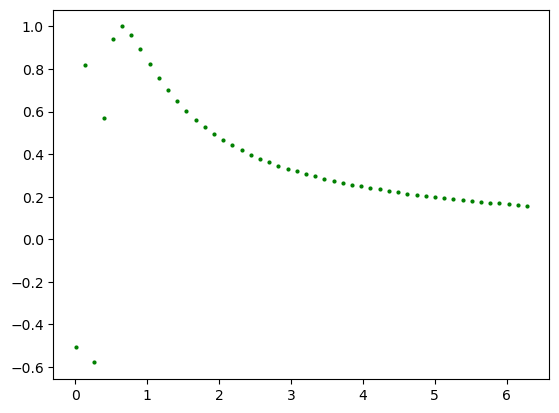

In [ ]:
#a)

def f(x):
    return np.sin(1/x)

a = 0.01
b = 2*np.pi

xvals = np.linspace(a,b,50)
yvals = f(xvals)

plt.scatter(xvals,yvals,c='g',s=4)
plt.show()




This graph is clearly not smooth, so we might have some difficulty with using GQ to evaluate this.

In [29]:
#b)

N = 5 #starting sample points

x,w = gaussxw(N,a,b)

I = 0.0
for k in range(N):
    I += w[k]*f(x[k])
print('The integral for N =',N,'points is',I)


desiredaccuracy = 1e-5 #larger than the stipulated accuracy in the problem to avoid an infinite loop
NewI = 0
error = NewI - I
NewN = N
while np.abs(error)>=desiredaccuracy:
    NewN *= 2
    x,w = gaussxw(NewN,a,b)
    NewI = 0.0
    for k in range(NewN):
        NewI += w[k]*f(x[k])
    error = NewI - I
    print(NewN,NewI,error)
    
print('The new value of the integral is',NewI,'with N =',NewN,'and an error of',error,'which is less than',desiredaccuracy)





The integral for N = 5 points is 1.8330645439986597
10 2.1795836819165104 0.3465191379178507
20 2.3948584800669477 0.561793936068288
40 2.3031574328396247 0.470092888840965
80 2.232173285628022 0.3991087416293624
160 2.2669528361572295 0.43388829215856983


KeyboardInterrupt: 

This was stalling, so I decided to move to the next section of the lab rather than letting this cook for too long. I suspect my method is accurate although I have not generated an answer.

## Infinite integrals (22 pts)

Let's evaluate the integral: 

$$ \int_0^\infty \frac{x^2}{\sqrt{x}}e^{-x}dx $$

I don't want to do this by hand, so let's do it computationally. 

*Note: don't forget to put brief comments in your code*

#### Step 1: Define the variable substitution you will make for to solve this problem. This should be done in markdown using LaTex formatting. 

The variable substitution I am using is 
$$
\begin{align*}
z &= \frac{x}{1+x} \\
x &= \frac{z}{1-z} \\
dx &= \frac{1}{(1-z)^2}dz \\
f(z) &= \frac{z^{3/2}}{(1-z)^{7/2}}\cdot e^{-z/(1-z)}~dz
\end{align*}
$$
With bounds from $0\leq z\leq1$.

#### Step 2: Define the function to use in the next step for integration

In [30]:
def f(z):
    numerator = z**(3/2) * np.exp(-z/(1-z))
    denominator = (1-z)**(7/2)
    return numerator/denominator



#### Step 3: Evaluate the integral using Gaussian Quadrature with 20 sample points

In [32]:
a = 0
b = 1
N = 20

z,w = gaussxw(N,a,b)

I = 0.0
for k in range(N):
    I += w[k]*f(z[k])
print('The value of the integral for N =',N,'sample points is I =',I)




The value of the integral for N = 20 sample points is I = 1.329351059221939


#### Step 4: Include a markdown explaining the process and result. Include how your answer compares to the answer of $\frac{3\sqrt{\pi}}{4}$

The expected answer of $3/4\pi$ is $\approx1.329340388$. Compared to our calculated value of $I$, the error is $\delta\approx1.067\times10^{-5}$.

At this point, I ran out of time in the lab, and so I had to stop here without doing the last problem.

## Multiple integrals (22 pts)

Let's find the mass of a metal plate that is 3 meters wide (in the $x$ direction) and 2 meters tall ($y$ direction), with a nonuniform density of (in kg/$\text{m}^2$)

$$ \sigma(x,y) = (\sin(\pi x)+1)y $$

Hint 1: the total mass is given by: $$M = \iint_R \sigma(x,y) \hspace{1mm} dA$$

*Note: don't forget to put brief comments in your code*

#### Step 1: Write the full equation for the double integral in markdown. (Hint: you'll need to swithch the cell to markdown and then you can use some of my latex coding from the cell above this)

#### Step 2: Define the function to use in the next step for integration

#### Step 3: Evaluate the double integral using double Gaussian quadrature for 100 sample points along each axis. 

#### Step 4: Include a markdown explaining the process and result. Include how your answer compares to the answer of $\frac{4}{\pi}+6 \simeq 7.2732395$